# Hotel Booking Analysis

## Project Overview

This project analyzes hotel booking data for 2025 using Python and Pandas.

The analysis focuses on booking trends, room types, booking channels, cancellations, and booking amounts.

The goal is to identify key patterns and provide useful business insights.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_excel("../Dataset/Hotel_Booking_Analysis_Dataset.xlsx")

## Data Overview

Initial inspection of the dataset structure, data types, and sample records.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   BookingID      2500 non-null   int64         
 1   BookingDate    2500 non-null   datetime64[us]
 2   CheckIn        2500 non-null   datetime64[us]
 3   CheckOut       2500 non-null   datetime64[us]
 4   Country        2500 non-null   str           
 5   RoomType       2500 non-null   str           
 6   Channel        2500 non-null   str           
 7   Status         2500 non-null   str           
 8   PricePerNight  2500 non-null   int64         
 9   Nights         2500 non-null   int64         
 10  TotalAmount    2500 non-null   int64         
dtypes: datetime64[us](3), int64(4), str(4)
memory usage: 215.0 KB


In [4]:
df.head()

,BookingID,BookingDate,CheckIn,CheckOut,Country,RoomType,Channel,Status,PricePerNight,Nights,TotalAmount
0,1,2025-10-31,2025-11-16,2025-11-19,China,Deluxe,Phone,Checked-out,71,3,213
1,2,2025-03-25,2025-03-28,2025-04-02,Korea,Standard,Walk-in,Checked-out,43,5,215
2,3,2025-11-02,2025-11-23,2025-11-25,Turkey,Family,Booking,Checked-out,92,2,184
3,4,2025-08-26,2025-09-17,2025-09-24,Kazakhstan,Standard,Booking,Cancelled,64,7,448
4,5,2025-03-19,2025-04-01,2025-04-03,UAE,Suite,Website,Checked-out,138,2,276


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 2500
Columns: 11


## Data Quality Checks

Checking the dataset for missing values, duplicate records, unique booking IDs, and category consistency.

In [6]:
print(df.isnull().sum())

BookingID        0
BookingDate      0
CheckIn          0
CheckOut         0
Country          0
RoomType         0
Channel          0
Status           0
PricePerNight    0
Nights           0
TotalAmount      0
dtype: int64


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['BookingID'].nunique()

2500

In [9]:
df['Status'].unique()

<StringArray>
['Checked-out', 'Cancelled', 'No-show']
Length: 3, dtype: str

In [10]:
print("RoomType:", df['RoomType'].unique())
print("Channel:", df['Channel'].unique())
print("Country:", df['Country'].unique())

RoomType: <StringArray>
['Deluxe', 'Standard', 'Family', 'Suite']
Length: 4, dtype: str
Channel: <StringArray>
['Phone', 'Walk-in', 'Booking', 'Website', 'Agoda']
Length: 5, dtype: str
Country: <StringArray>
[     'China',      'Korea',     'Turkey', 'Kazakhstan',        'UAE',
 'Uzbekistan',     'Russia',    'Germany']
Length: 8, dtype: str


## Data Validation

Validating that TotalAmount is consistent with PricePerNight and Nights.

In [11]:
(df['PricePerNight'] * df['Nights'] != df['TotalAmount']).sum()

np.int64(0)

## Basic Analysis

Calculating key booking metrics and comparing booking performance across statuses, room types, channels, and countries.

In [12]:
print("Total Bookings:", len(df))
print("Total Booking Amount:", df['TotalAmount'].sum())
print("Average Booking Amount:", df['TotalAmount'].mean())

print("\nBookings by Status:")
print(df['Status'].value_counts())

print("\nBookings by Room Type:")
print(df['RoomType'].value_counts())

print("\nBookings by Channel:")
print(df['Channel'].value_counts())

Total Bookings: 2500
Total Booking Amount: 955998
Average Booking Amount: 382.3992

Bookings by Status:
Status
Checked-out    1906
Cancelled       483
No-show         111
Name: count, dtype: int64

Bookings by Room Type:
RoomType
Family      661
Standard    650
Suite       619
Deluxe      570
Name: count, dtype: int64

Bookings by Channel:
Channel
Booking    514
Website    513
Agoda      504
Phone      487
Walk-in    482
Name: count, dtype: int64


In [13]:
print("Cancelled Bookings:", df[df['Status'] == 'Cancelled'].shape[0])
print("Checked-out Bookings:", df[df['Status'] == 'Checked-out'].shape[0])
print("Cancellation Rate:", (df[df['Status'] == 'Cancelled'].shape[0] / len(df)) * 100, "%")

Cancelled Bookings: 483
Checked-out Bookings: 1906
Cancellation Rate: 19.32 %


In [14]:
print("\nTotal Amount by Room Type:")
print(df.groupby('RoomType')['TotalAmount'].sum())

print("\nAverage Amount by Room Type:")
print(df.groupby('RoomType')['TotalAmount'].mean())

print("\nTotal Amount by Channel:")
print(df.groupby('Channel')['TotalAmount'].sum())

print("\nBookings by Country:")
print(df.groupby('Country')['BookingID'].count())

print("\nAverage Price Per Night by Room Type:")
print(df.groupby('RoomType')['PricePerNight'].mean())

print("\nTotal Amount Statistics by Room Type:")
print(df.groupby('RoomType')['TotalAmount'].agg(['count', 'sum', 'mean']))


Total Amount by Room Type:
RoomType
Deluxe      184636
Family      262103
Standard    138163
Suite       371096
Name: TotalAmount, dtype: int64

Average Amount by Room Type:
RoomType
Deluxe      323.922807
Family      396.524962
Standard    212.558462
Suite       599.508885
Name: TotalAmount, dtype: float64

Total Amount by Channel:
Channel
Agoda      189107
Booking    207099
Phone      191594
Walk-in    176495
Website    191703
Name: TotalAmount, dtype: int64

Bookings by Country:
Country
China         324
Germany       346
Kazakhstan    281
Korea         303
Russia        346
Turkey        254
UAE           317
Uzbekistan    329
Name: BookingID, dtype: int64

Average Price Per Night by Room Type:
RoomType
Deluxe       78.545614
Family       97.756430
Standard     53.027692
Suite       147.329564
Name: PricePerNight, dtype: float64

Total Amount Statistics by Room Type:
          count     sum        mean
RoomType                           
Deluxe      570  184636  323.922807
Family 

## Time Analysis

Analyzing monthly booking trends, booking amounts, and booking lead time.

In [15]:
df['BookingMonth'] = df['BookingDate'].dt.month
monthly_bookings = df.groupby('BookingMonth')['BookingID'].size()
monthly_amount = df.groupby('BookingMonth')['TotalAmount'].sum()
print("\nPeak Booking Month:", monthly_bookings.idxmax(), "with", monthly_bookings.max(), "bookings.")
print("\nPeak Booking Amount Month:", monthly_amount.idxmax(), "with", monthly_amount.max(), "in total booking amount.")


Peak Booking Month: 4 with 225 bookings.

Peak Booking Amount Month: 3 with 92183 in total booking amount.


In [16]:
df['LeadTime'] = (df['CheckIn'] - df['BookingDate']).dt.days

print("Negative Lead Time:", (df['LeadTime'] < 0).sum())

print("\nMin Lead Time:")
print(df['LeadTime'].min())
print("\nMax Lead Time:")
print(df['LeadTime'].max())
print("\nAverage Lead Time:")
print(df['LeadTime'].mean())

print("\nAverage Lead Time by Room Type:")
print(df.groupby('RoomType')['LeadTime'].mean())

print("\nAverage Nights by Room Type:")
print(df.groupby('RoomType')['Nights'].mean())



Negative Lead Time: 0

Min Lead Time:
0

Max Lead Time:
30

Average Lead Time:
15.2096

Average Lead Time by Room Type:
RoomType
Deluxe      15.345614
Family      15.036309
Standard    15.493846
Suite       14.970921
Name: LeadTime, dtype: float64

Average Nights by Room Type:
RoomType
Deluxe      4.119298
Family      4.054463
Standard    4.016923
Suite       4.067851
Name: Nights, dtype: float64


## Cancellation Analysis

Analyzing cancellation trends by month and booking channel.

In [17]:
monthly_cancelled = (
    df[df['Status'] == 'Cancelled']
    .groupby('BookingMonth')
    .size()
)

monthly_cancellation_rate = (
    monthly_cancelled / monthly_bookings * 100
).round(2)

print("Cancelled Bookings by Month:")
print(monthly_cancelled)

print("\nCancellation Rate by Month:")
print(monthly_cancellation_rate)


channel_total = df.groupby('Channel').size()

channel_cancelled = (
    df[df['Status'] == 'Cancelled']
    .groupby('Channel')
    .size()
)

channel_rate = (
    channel_cancelled / channel_total * 100
).round(2)

print("\nCancellation Rate by Channel:")
print(channel_rate)

Cancelled Bookings by Month:
BookingMonth
1     32
2     36
3     48
4     45
5     52
6     43
7     31
8     43
9     46
10    32
11    28
12    47
dtype: int64

Cancellation Rate by Month:
BookingMonth
1     16.75
2     18.00
3     21.62
4     20.00
5     24.30
6     20.09
7     14.55
8     19.82
9     21.10
10    16.58
11    14.74
12    23.15
dtype: float64

Cancellation Rate by Channel:
Channel
Agoda      19.64
Booking    21.60
Phone      16.63
Walk-in    18.88
Website    19.69
dtype: float64


## Room Type and Booking Pattern Analysis

Exploring booking amounts by room type and identifying patterns across months.

In [18]:
room_month = df.pivot_table(
    index='BookingMonth',
    columns='RoomType',
    values='TotalAmount',
    aggfunc='sum'
)

print(room_month)

print("\nAverage Total Amount by Room Type:")
print(df.groupby('RoomType')['TotalAmount'].mean().sort_values(ascending=False))

print("\nAverage Lead Time by Status:")
print(df.groupby('Status')['LeadTime'].mean())


RoomType      Deluxe  Family  Standard  Suite
BookingMonth                                 
1              15592   19827     10665  24808
2              15671   21551     11058  31927
3              16327   21445     10989  43422
4              17037   23160     12955  32253
5              14453   21895     10699  31325
6              17468   23366     13435  25983
7              14812   21964      8698  31063
8              15819   23890     11585  29275
9              12800   25161     11128  33825
10             12628   17710     14178  23978
11             16269   21115      9551  31074
12             15760   21019     13222  32163

Average Total Amount by Room Type:
RoomType
Suite       599.508885
Family      396.524962
Deluxe      323.922807
Standard    212.558462
Name: TotalAmount, dtype: float64

Average Lead Time by Status:
Status
Cancelled      14.645963
Checked-out    15.362539
No-show        15.036036
Name: LeadTime, dtype: float64


## Visualizations

Visualizing key booking trends, cancellation patterns, and room type performance.

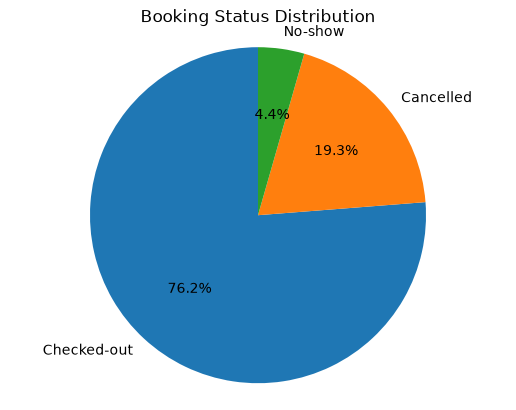

In [19]:
status_count = df['Status'].value_counts()

plt.pie(status_count, labels=status_count.index, autopct='%1.1f%%', startangle=90)
plt.title('Booking Status Distribution')
plt.axis('equal')

plt.show()

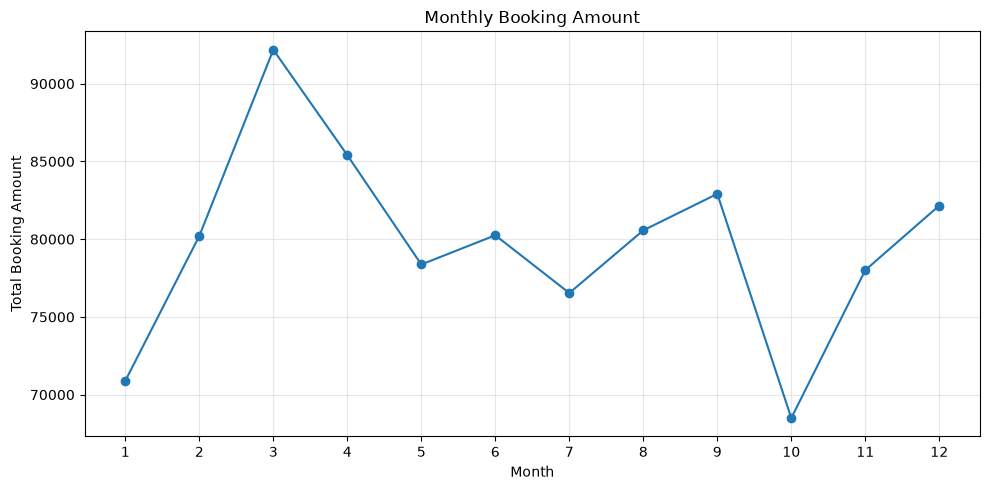

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_amount.index,
    monthly_amount.values,
    marker='o'
)

plt.title('Monthly Booking Amount')
plt.xlabel('Month')
plt.ylabel('Total Booking Amount')

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

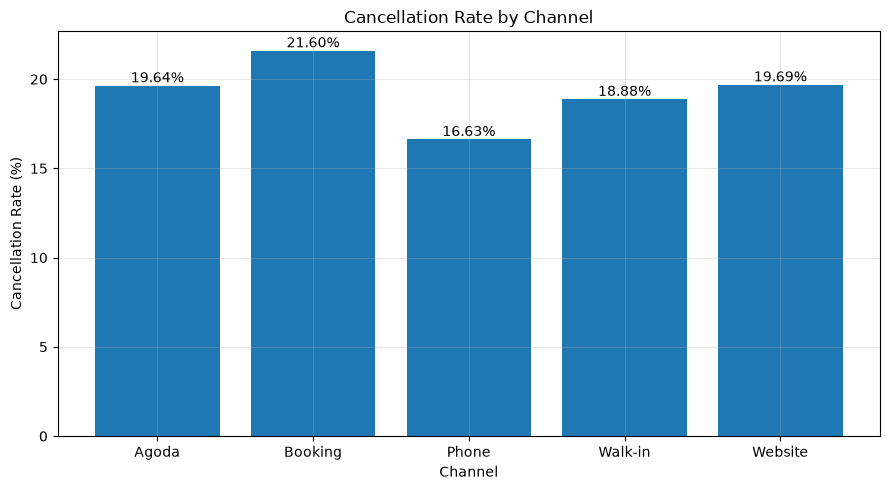

In [21]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    channel_rate.index,
    channel_rate.values
)

plt.bar_label(bars, fmt='%.2f%%')

plt.title('Cancellation Rate by Channel')
plt.xlabel('Channel')
plt.ylabel('Cancellation Rate (%)')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

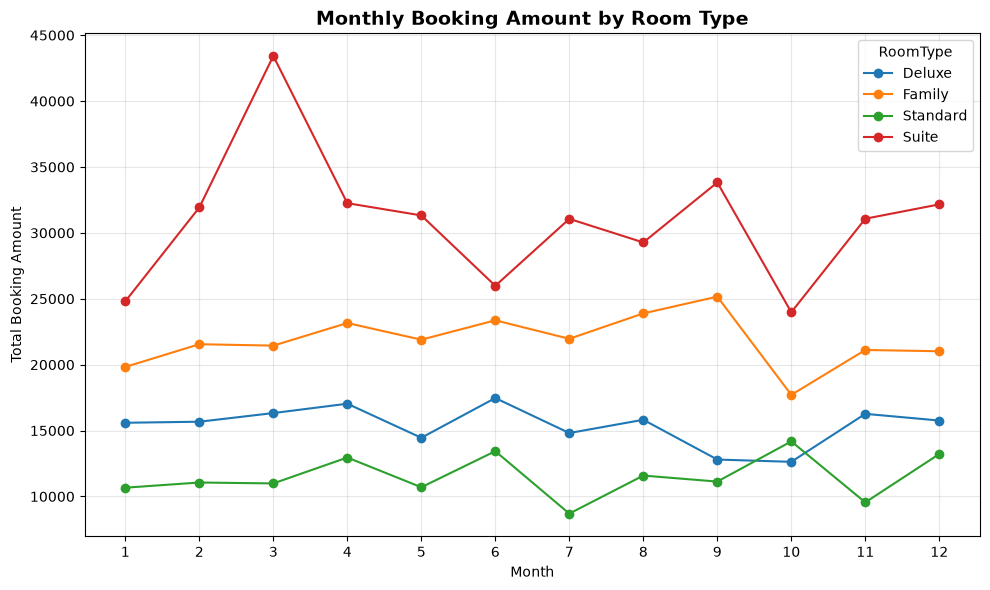

In [22]:
room_month.plot(
    figsize=(10, 6),
    marker='o'
)

plt.title('Monthly Booking Amount by Room Type', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Booking Amount')

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Key Insights

### 1. Monthly Booking Activity

Booking activity varied throughout the year. April recorded the highest number of bookings, while November had the lowest.

### 2. March Had the Highest Booking Amount

March recorded the highest total booking amount, although April had the highest number of bookings.

Further analysis showed that Suite bookings generated approximately 43K in March — the highest monthly booking amount for this room type during the year. This contributed significantly to March's overall booking amount.

### 3. Room Type Performance

Family was the most frequently booked room type with 661 bookings, followed by Standard with 650 bookings. Deluxe had the lowest number of bookings with 570.

Suite generated the highest total booking amount among all room types throughout the year.

### 4. Booking Channels

Booking and Website were the leading booking channels with 514 and 513 bookings respectively. However, booking volume was relatively evenly distributed across all five channels.

The relatively balanced channel distribution suggests that the hotel was not heavily dependent on a single booking channel.

### 5. Cancellation Analysis

483 out of 2,500 bookings were cancelled, resulting in a cancellation rate of 19.32%. This means approximately 1 in 5 bookings was cancelled.

Cancellation rates were relatively similar across booking channels, so no single channel appeared to be the main driver of cancellations.

### 6. Booking Status

76.24% of bookings were completed (Checked-out), 19.32% were cancelled, and 4.44% resulted in No-show.